In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
warnings.filterwarnings('ignore')

main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 

from ciim.src.tf_activity.helper import adata_lambda
from ciim.src.common import surrogate_names, colors_blind
from ciim.src.utils.util import plot_umap

datasets = ['data1', 'data7_allTPs_jalil']
cell_types = ['CD4T', 'CD8T', 'NK', 'MONO', 'B']


# UMAP

In [2]:
to_save = f'/vol/projects/jnourisa/datasets/umap/'
os.makedirs(to_save, exist_ok=True)
!ls {to_save}

data1_umap.h5ad  data7_allTPs_jalil_umap.h5ad


In [3]:
if False:
    lambda_sc_adata = lambda dataaset:  f'/vol/projects/jnourisa/datasets/{dataset}_raw.h5ad'
    for dataset in datasets:
        adata = ad.read_h5ad(lambda_sc_adata(dataset))
        adata.obs['Major_CT'].dropna(inplace=True)
        adata = adata[adata.obs['Major_CT'].isin(cell_types)]
        adata.obs['Major_CT'] = pd.Categorical(adata.obs['Major_CT'], categories=cell_types, ordered=True)

        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=2000)

        sc.pp.pca(adata, use_highly_variable=True)  
        sc.pp.neighbors(adata, n_neighbors=15)  
        sc.tl.umap(adata)  
        adata.write(f'{to_save}/{dataset}_umap.h5ad')
else:
    adata_dict = {}
    for dataset in datasets:
        adata = ad.read_h5ad(f'{to_save}/{dataset}_umap.h5ad')
        adata_dict[dataset] = adata

In [4]:
adata1 = adata_dict[datasets[0]]
adata2 = adata_dict[datasets[1]]
adata1_sub = adata1[adata1.obs['Major_CT'].isin(['MONO', 'CD8T'])]
adata2_sub = adata2[adata2.obs['Major_CT'].isin(['MONO', 'CD8T'])]

In [6]:
# Color palette mapping for your cell types
cell_type_palette = {
    'Tem_Trm_CD8': '#1f77b4',    # Blue
    'Tem_Temra_CD8': '#ff7f0e',   # Orange
    'Tcm_Naive_CD8': '#2ca02c',   # Green
    'NonClassic_MONO': '#d62728', # Red
    'Classic_MONO': '#9467bd',    # Purple
    'MAIT': '#8c564b'             # Brown
}


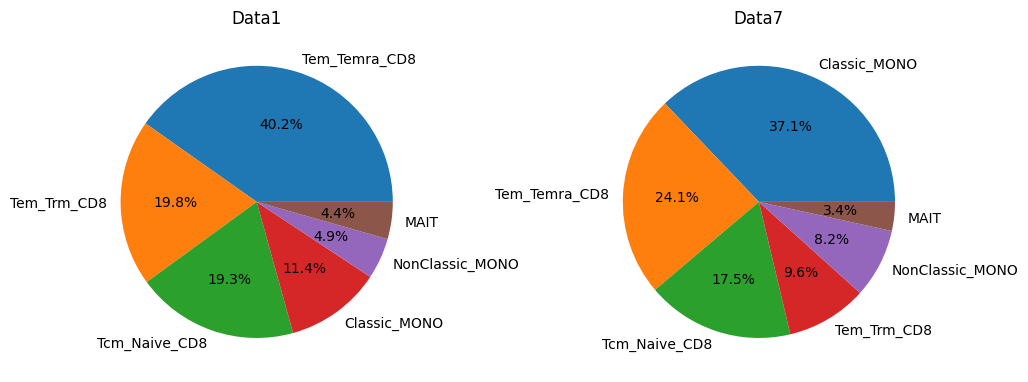

In [7]:
import matplotlib.pyplot as plt

# Get the count of each cell type
cell_type_counts1 = adata1_sub.obs['Sub_CT'].value_counts()
cell_type_counts2 = adata2_sub.obs['Sub_CT'].value_counts()

def pieplot(df, ax):
    df.plot(kind='pie', autopct='%1.1f%%', colors=list(cell_type_palette.values()), ax=ax)
    ax.set_ylabel('')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
pieplot(cell_type_counts1, ax)
ax.set_title('Data1')
ax = axes[1]
pieplot(cell_type_counts2, ax)
ax.set_title('Data7')
plt.tight_layout()

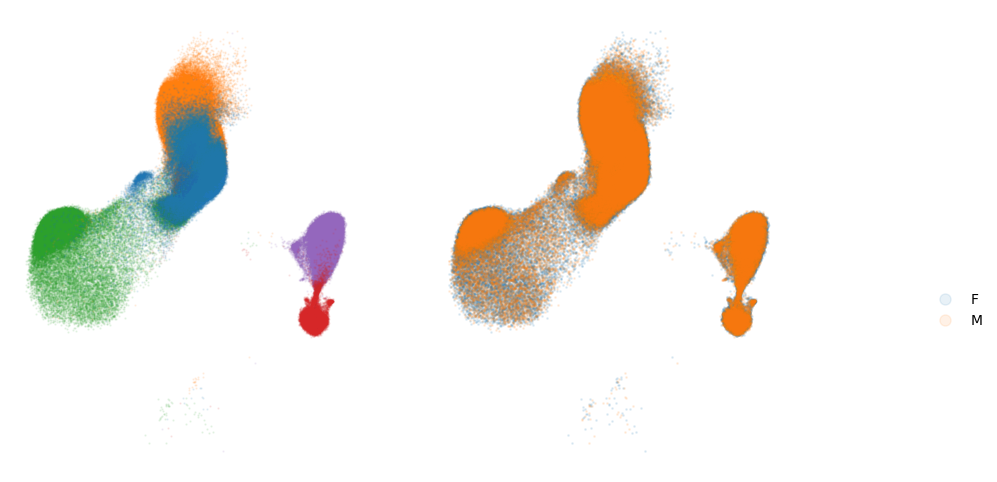

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
ax = axes[0]
plot_umap(adata1_sub, color='Sub_CT', ax=ax, s=.4, X_label='X_umap', alpha=0.1, palette=cell_type_palette)  
ax = axes[1]

plot_umap(adata2_sub, color='Sub_CT', ax=ax, s=.4, X_label='X_umap', alpha=0.1, palette=cell_type_palette)  
  
# plt.savefig(f'output/figs/umap_{dataset}.png', dpi=300, bbox_inches='tight')

# Cell count: pseudobulking

In [8]:
# from task_grn_inference.src.exp_analysis.helper import plot_cumulative_density
# fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)
# for i, dataset in enumerate(par['datasets']):
#     adata = adata_lambda(dataset)
#     cell_count = adata.obs['cell_count']
#     plot_cumulative_density(cell_count, ax=ax, label=dataset)
#     ax.set_xlabel('Cell count')
#     ax.set_ylabel('Cumulative density')
#     ax.set_xscale('log')
# plt.legend(loc=(1, .5))

# Dataset overview

In [45]:
# UMAP of pseudo bulked expression 
def plot_embeding(dataset):
    
    adata = adata_lambda(dataset)
    sc.pp.neighbors(adata, n_neighbors=10)
    sc.tl.umap(adata)

    size_values = 3*(adata.obs['cell_count'] / adata.obs['cell_count'].max() * 100)  
    sc.pl.umap(adata, color=['cell_type', 'sex'], wspace=0.3, size=size_values, title=dataset)
    sc.pl.pca(adata, color=['cell_type', 'sex'], wspace=0.3, size=size_values, title=dataset)
if False:
    plot_embeding('data1')

## Data7

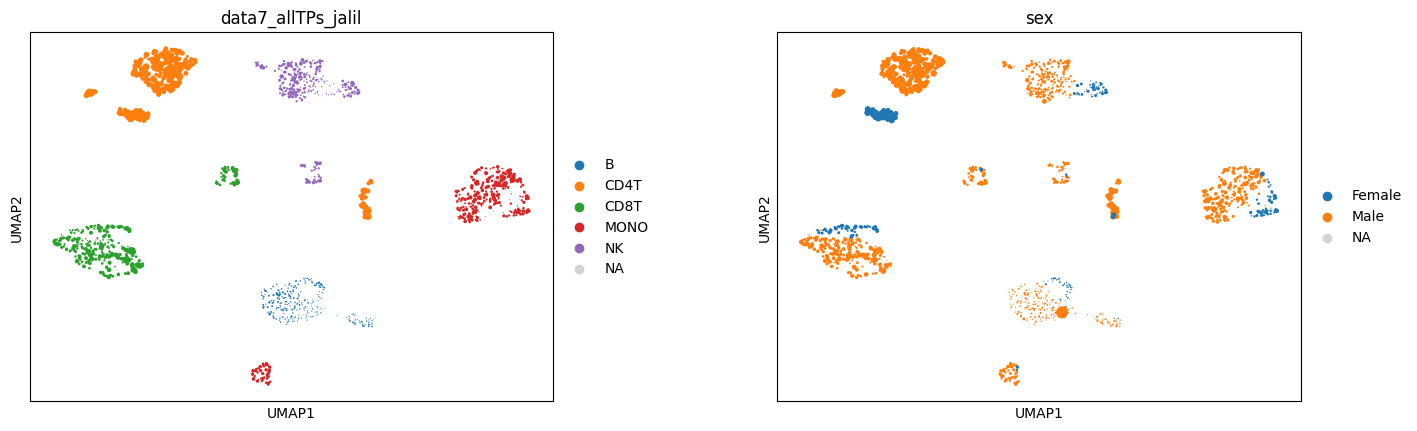

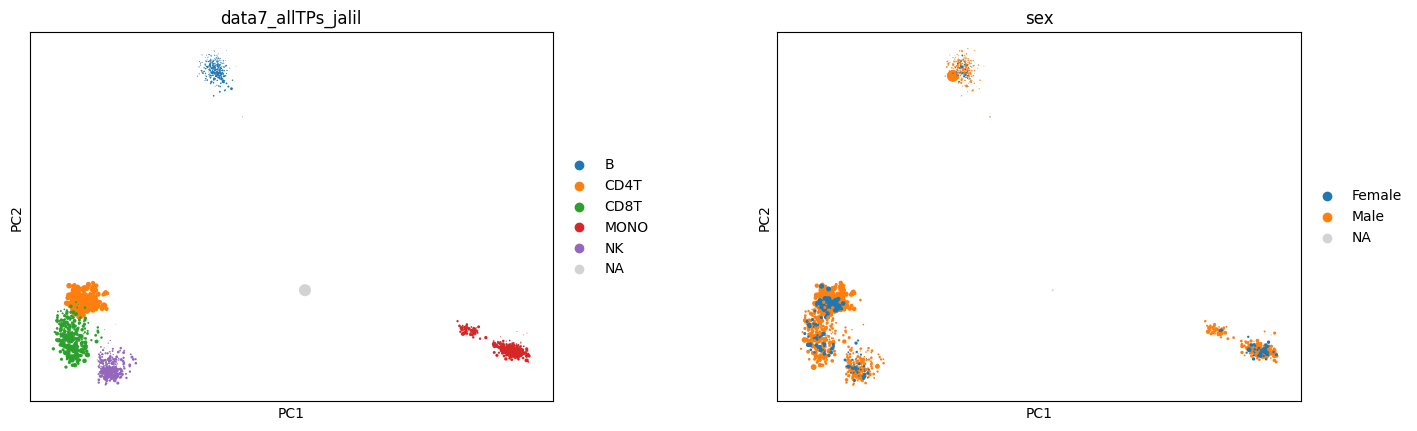

## Data1

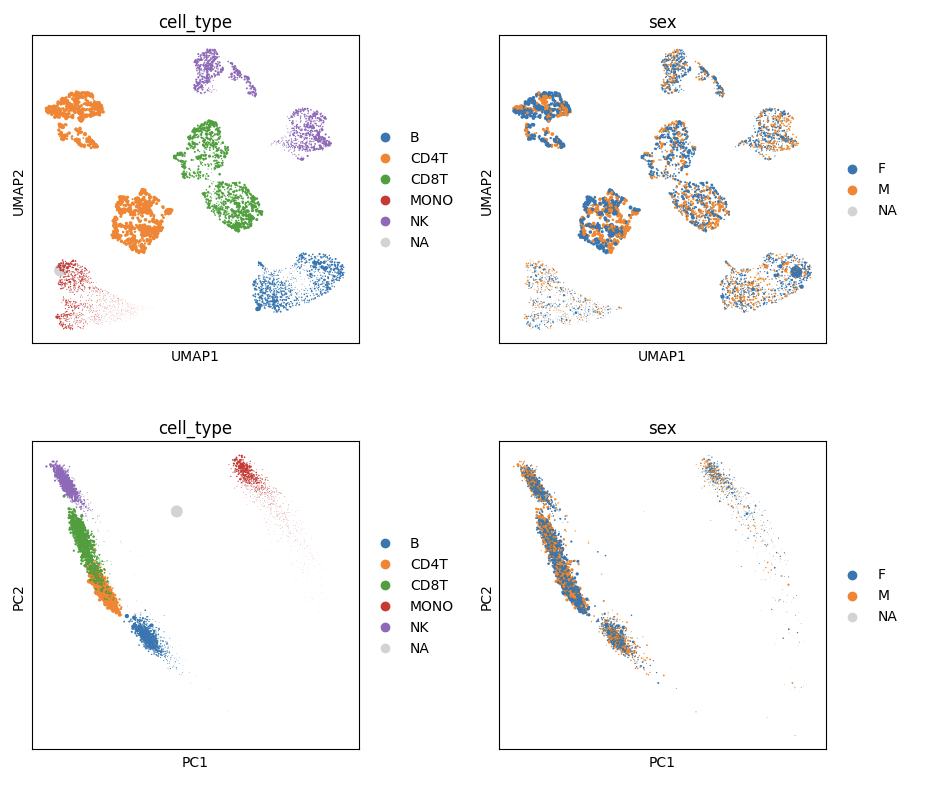

In [24]:
data_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    n_donors = adata.obs['donor_id'].nunique()
    n_age_donors = adata.obs['age_donor'].nunique()
    data_store.append({'Dataset': dataset, 'Gene': adata.n_vars, 'Donors': n_donors, 'Donors (age)': n_age_donors})
df = pd.DataFrame(data_store)
df['Dataset'] = df['Dataset'].map(surrogate_names)
df.head()

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,Dataset,Gene,Donors,Donors (age)
0,Dataset 1,17001,981,981
1,Dataset 2,24516,166,313


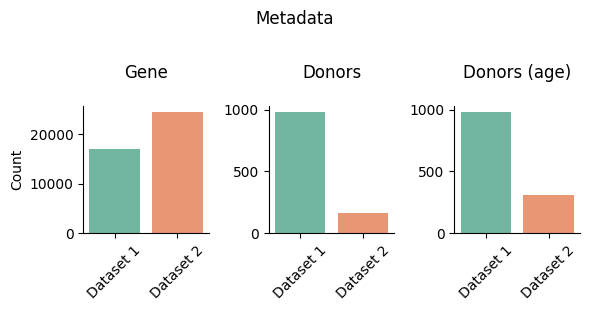

In [46]:

# Convert DataFrame to long format for easier plotting
df_long = df.melt(id_vars=["Dataset"], var_name="Metadata", value_name="Count")

# Plot using seaborn
fig, axes = plt.subplots(1, 3, figsize=(6, 3))
for i, metadata in enumerate(['Gene', 'Donors', 'Donors (age)']):
    ax = axes[i]
    sns.barplot(data=df, x='Dataset', y=metadata, ax=ax, hue='Dataset', palette='Set2', legend=False)
    ax.set_title(metadata, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i==0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    ax.set_xlabel("")
    ax.legend().remove()

plt.xticks(rotation=45)
plt.suptitle("Metadata", y=1.02)
plt.tight_layout()
plt.show()

In [4]:
dataset = datasets[0]
adata = adata_lambda(dataset)

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


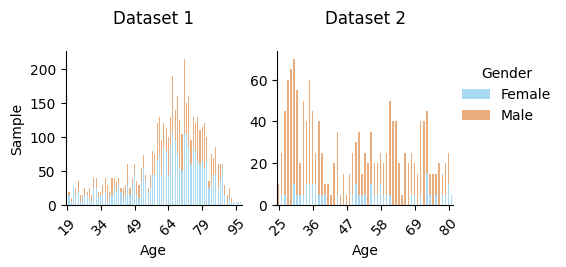

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create subplots (one per dataset)
fig, axes = plt.subplots(1, len(datasets), figsize=(5, 2), sharey=False)

for i, dataset in enumerate(datasets):
    adata = adata_lambda(dataset)
    
    df = adata.obs.copy()
    df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))

    # Count occurrences of each sex within each age group
    df_count = df.groupby(['age', 'sex']).size().reset_index(name='count')

    # Pivot data for stacking
    df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

    # Plot stacked bar chart
    
    palette = {gender: color for gender, color in zip(['Female','Male'], ['#56B4E9', '#D55E00'])}
    df_pivot.plot(kind='bar', stacked=True, ax=axes[i], color=palette, edgecolor=None, alpha=0.5)

    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Sample" if i == 0 else "")  # Only first plot has y-label
    axes[i].set_title(surrogate_names[dataset], pad=20)

    # Adjust xticks to show fewer labels
    xtick_labels = [int(float(label.get_text())) for label in axes[i].get_xticklabels()]
    step = max(1, len(xtick_labels) // 5)  # Show ~5 evenly spaced labels
    axes[i].set_xticks(range(0, len(xtick_labels), step))
    axes[i].set_xticklabels(xtick_labels[::step], rotation=45)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    if i == 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(loc=(1.02, .5), frameon=False, title='Gender')

plt.show()